# Pedestrians intention detection

In [ ]:
!nvidia-smi

Tue Apr 29 06:50:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
from google.colab import drive
import pandas as pd
from tensorflow.keras.utils import plot_model

import os
import cv2
# import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model




drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Extract and Save the Frames The CVAt Premium Features (just Once and already Done by saving extracted frames and labels)

In [ ]:
import cv2
import os

def save_video_frames_in_range(video_path, output_dir, start_frame=0, end_frame=500):
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"[INFO] Total video frames: {total_frames}")
    print(f"[INFO] Extracting from frame {start_frame} to {end_frame}...")

    # Set the video reader to the starting frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    idx = start_frame
    saved = 0

    # Loop through the desired frame range
    while idx < end_frame:
        success, frame = cap.read()
        if not success:
            break
        # Save each frame as a JPEG file with a padded filename
        frame_filename = os.path.join(output_dir, f"frame_{idx:05d}.jpg")
        cv2.imwrite(frame_filename, frame)
        idx += 1
        saved += 1

    cap.release()
    print(f"[DONE] Saved {saved} frames to {output_dir}")

In [ ]:
# Save the first 500 frames
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames", 0, 500)

NameError: name 'VIDEO_PATH' is not defined

In [ ]:
# Save the next 500 frames (from 500 to 1000)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames", 500, 1000)

In [ ]:
# Save the next 500 frames (from 1000 to 1500)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",1000,1500)

In [ ]:
# Save the next 500 frames (from 1500 to 2000)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",1500,2000)

In [ ]:
# Save the next 500 frames (from 2000 to 2500)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",2000,2500)

In [ ]:
# Save the next 500 frames (from 2500 to 3000)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",2500,3000)

In [ ]:
# Save the next 500 frames (from 3000 to 4000)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",3000,4000)

In [ ]:
# Save the next 500 frames (from 4000 to 4507)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",4000,4507)

In [ ]:
XML_PATH = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/annotations-1.xml"
LABELS = {'Walking': 0, 'Standing': 1, 'Crossing': 2}

# 1. Parse annotations from XML
def parse_cvat_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    annotations = defaultdict(list)

    for track in root.findall("track"):
        label = track.attrib["label"]
        if label not in LABELS:
            continue
        track_id = int(track.attrib["id"])
        for box in track.findall("box"):
            frame = int(box.attrib["frame"])
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = int(box.attrib["outside"])
            if outside == 1:
                continue
            annotations[track_id].append({
                "frame": frame,
                "bbox": [int(xtl), int(ytl), int(xbr), int(ybr)],
                "label": LABELS[label]
            })
    return annotations

# 2. Count total frames
def get_total_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f"[INFO] Total frames: {total}")
    return total

# 3. Save all frames into a folder
def save_all_frames(video_path, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    cap = cv2.VideoCapture(video_path)
    idx = 0
    while True:
        success, frame = cap.read()
        if not success:
            break
        frame_name = f"frame_{idx:05d}.jpg"
        frame_path = os.path.join(output_dir, frame_name)
        cv2.imwrite(frame_path, frame)
        idx += 1
    cap.release()
    print(f"[INFO] Saved {idx} frames.")

def create_csv_with_labels(annotations, frames_folder, output_csv):
    rows = []
    for track_id, boxes in annotations.items():
        for box in boxes:
            frame_number = box['frame']
            label_id = box['label']
            label_name = [k for k, v in LABELS.items() if v == label_id][0]
            xtl, ytl, xbr, ybr = box['bbox']
            image_name = f"frame_{frame_number:05d}.jpg"
            rows.append([
                frame_number, image_name, label_name, label_id,
                xtl, ytl, xbr, ybr, track_id
            ])
    with open(output_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'frame', 'image_name', 'label', 'label_id',
            'xtl', 'ytl', 'xbr', 'ybr', 'track_id'
        ])
        writer.writerows(rows)
    print(f"[INFO] CSV saved to {output_csv}")



In [ ]:
import csv
FRAMES_FOLDER="/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames"
annotations = parse_cvat_xml(XML_PATH)
create_csv_with_labels(annotations, FRAMES_FOLDER, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/frames_labels.csv")

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/frames_labels.csv")

df.head()

In [ ]:
def extract_crossing_attributes(xml_path, frames_folder, label_filter='Crossing'):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    rows = []

    for track in root.findall("track"):
        label = track.attrib["label"]
        if label != label_filter:
            continue
        track_id = int(track.attrib["id"])

        for box in track.findall("box"):
            frame = int(box.attrib["frame"])
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = int(box.attrib["outside"])
            if outside == 1:
                continue

            attr_dict = {
                "frame": frame,
                "image_path": os.path.join(frames_folder, f"frame_{frame:05d}.jpg"),
                "track_id": track_id,
                "xtl": xtl,
                "ytl": ytl,
                "xbr": xbr,
                "ybr": ybr,
                "label": label
            }

            # Add nested <attribute> tags
            for attr in box.findall("attribute"):
                attr_name = attr.attrib.get("name")
                attr_value = attr.text
                attr_dict[attr_name] = attr_value

            rows.append(attr_dict)

    return pd.DataFrame(rows)

# Run and save
print("[INFO] Extracting 'Crossing' attributes...")
df_crossing = extract_crossing_attributes(XML_PATH, FRAMES_FOLDER)
df_crossing.to_csv("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/crossing_annotations.csv", index=False)
print("[DONE] Saved crossing_annotations.csv with", len(df_crossing), "rows.")


In [ ]:
df_crossing=pd.read_csv("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/crossing_annotations.csv")

In [ ]:
df_crossing.tail()

In [ ]:
# Configs
CSV_PATH        = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/frames_labels.csv"
FRAMES_FOLDER   = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames"
SEQUENCE_LENGTH = 10
IMAGE_SIZE      = (128, 128)

def preprocess_bbox(frame, bbox, size=IMAGE_SIZE):
    x1, y1, x2, y2 = bbox
    h, w, _ = frame.shape
    x1, y1 = max(0, int(x1)), max(0, int(y1))
    x2, y2 = min(w, int(x2)), min(h, int(y2))
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return cv2.resize(crop, size)

def generate_sequences_from_csv(csv_path, frames_folder, sequence_length=SEQUENCE_LENGTH):
    df = pd.read_csv(csv_path)
    # Build full path to each frame image
    df["image_path"] = df["image_name"].apply(lambda fn: os.path.join(frames_folder, fn))

    # Get the list of all image files in the frames folder
    existing_files = set(os.listdir(frames_folder))
    print("[DEBUG] Files found in frames folder:", len(existing_files))

    features, labels = [], []

    # Iterate over each pedestrian track
    for track_id, group in df.groupby("track_id"):
        group = group.sort_values("frame")
        records = group.to_dict(orient="records")

        # Skip if not enough frames
        if len(records) < sequence_length:
            continue

        # Sliding window over this track
        for start in range(len(records) - sequence_length + 1):
            seq_imgs = []
            for offset in range(sequence_length):
                rec = records[start + offset]
                frame_name = rec["image_name"]
                fp = os.path.join(frames_folder, frame_name)

                # Debug: Check if the frame file exists
                if frame_name not in existing_files:
                    print(f"[DEBUG] Missing frame: {fp}")
                    break

                img = cv2.imread(fp)
                if img is None:
                    print(f"[DEBUG] Failed to load frame: {fp}")
                    break

                crop = preprocess_bbox(img, [rec["xtl"], rec["ytl"], rec["xbr"], rec["ybr"]])
                if crop is None:
                    break
                seq_imgs.append(crop)

            if len(seq_imgs) == sequence_length:
                features.append(np.stack(seq_imgs, axis=0))
                labels.append(rec["label_id"])   # or rec["label"] if that's your numeric

    return np.array(features), np.array(labels)

# ——— Run everything ———
print("[INFO] Generating sequences from CSV…")
features, labels = generate_sequences_from_csv(CSV_PATH, FRAMES_FOLDER)

print("[INFO] Saving data…")
np.save("features.npy", features)
np.save("labels.npy", labels)

print(f"[DONE] Features shape: {features.shape}")
print(f"[DONE] Labels shape:   {labels.shape}")


[INFO] Generating sequences from CSV…
[DEBUG] Files found in frames folder: 4507
[INFO] Saving data…
[DONE] Features shape: (3374, 10, 128, 128, 3)
[DONE] Labels shape:   (3374,)


[INFO] Showing sequence 0 | Label: Walking


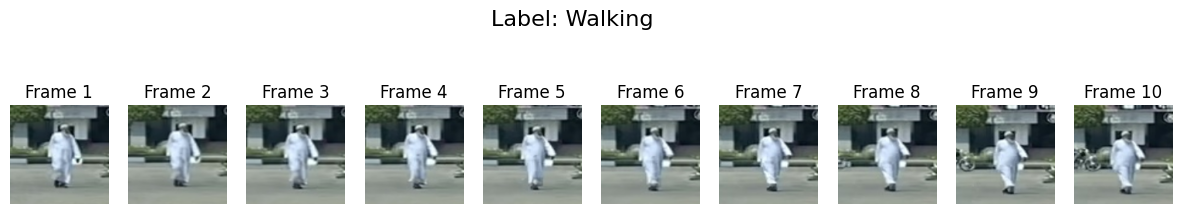

[INFO] Showing sequence 1 | Label: Walking


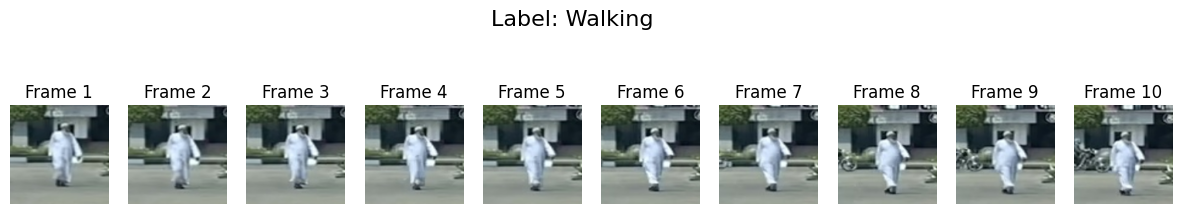

[INFO] Showing sequence 2 | Label: Walking


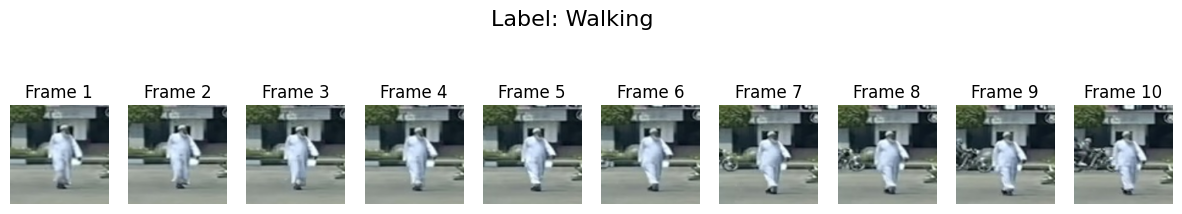

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved features and labels
features = np.load("features.npy")
labels = np.load("labels.npy")

# Reverse label map
LABELS_INV = {0: 'Walking', 1: 'Standing', 2: 'Crossing'}

# Visualize sequence using matplotlib
def visualize_sequence_matplotlib(sequence, label):
    plt.figure(figsize=(15, 3))
    for i, frame in enumerate(sequence):
        plt.subplot(1, len(sequence), i + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Frame {i+1}")
    plt.suptitle(f"Label: {LABELS_INV[label]}", fontsize=16)
    plt.show()

# Show the first 3 sequences
for i in range(3):
    print(f"[INFO] Showing sequence {i} | Label: {LABELS_INV[labels[i]]}")
    visualize_sequence_matplotlib(features[i], labels[i])


# Load the Cvat Data

In [ ]:
!pip install tqdm

In [ ]:
import cv2
import os
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict
from tqdm import tqdm

# CONFIG
VIDEO_PATH = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/v1.mov"
XML_PATH = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/annotations-1.xml"
SEQUENCE_LENGTH = 10  # <- reduced from 5
IMAGE_SIZE = (128, 128)  # <- reduced from (64, 64)
LABELS = {'Walking': 0, 'Standing': 1, 'Crossing': 2}
MAX_FRAMES = 500  # <- limit to avoid memory issues
MAX_TRACKS = 5    # <- limit number of tracks for testing

# 1. Parse XML annotations
def parse_cvat_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    annotations = defaultdict(list)

    for track in root.findall("track"):
        label = track.attrib["label"]
        if label not in LABELS:
            continue

        track_id = int(track.attrib["id"])
        for box in track.findall("box"):
            frame = int(box.attrib["frame"])
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = int(box.attrib["outside"])
            if outside == 1:
                continue
            annotations[track_id].append({
                "frame": frame,
                "bbox": [int(xtl), int(ytl), int(xbr), int(ybr)],
                "label": LABELS[label]
            })
    return annotations

# 2. Load limited video frames
def load_video_frames(video_path, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(video_path)
    frame_map = {}
    idx = 0
    success, frame = cap.read()
    while success and idx < max_frames:
        frame_map[idx] = frame
        idx += 1
        success, frame = cap.read()
    cap.release()
    return frame_map

# 3. Crop & resize bbox region
def preprocess_bbox(frame, bbox, size=IMAGE_SIZE):
    x1, y1, x2, y2 = bbox
    h, w, _ = frame.shape
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    crop = cv2.resize(crop, size)
    return crop

# 4. Generate sequences
def generate_sequences(annotations, frame_map, sequence_length=SEQUENCE_LENGTH):
    features, labels = [], []

    for track_id, boxes in list(annotations.items())[:MAX_TRACKS]:  # Limit tracks
        boxes = sorted(boxes, key=lambda x: x["frame"])
        if len(boxes) < sequence_length:
            continue

        for i in range(0, len(boxes) - sequence_length + 1):
            sequence = []
            for j in range(sequence_length):
                box_info = boxes[i + j]
                frame = frame_map.get(box_info["frame"])
                if frame is None:
                    break
                processed = preprocess_bbox(frame, box_info["bbox"])
                if processed is None:
                    break
                sequence.append(processed)
            if len(sequence) == sequence_length:
                features.append(np.array(sequence))
                labels.append(box_info["label"])

    return np.array(features), np.array(labels)

# 5. Run everything
print("[INFO] Parsing annotations...")
annotations = parse_cvat_xml(XML_PATH)

print("[INFO] Loading video frames (max:", MAX_FRAMES, ")...")
frame_map = load_video_frames(VIDEO_PATH, MAX_FRAMES)
print(f"[INFO] Loaded {len(frame_map)} frames.")

print("[INFO] Generating sequences...")
features, labels = generate_sequences(annotations, frame_map)

print("[INFO] Saving data...")
np.save("features.npy", features)
np.save("labels.npy", labels)

print("[DONE] Features shape:", features.shape)
print("[DONE] Labels shape:", labels.shape)


[INFO] Parsing annotations...
[INFO] Loading video frames (max: 500 )...
[INFO] Loaded 0 frames.
[INFO] Generating sequences...
[INFO] Saving data...
[DONE] Features shape: (0,)
[DONE] Labels shape: (0,)


In [ ]:
import pandas as pd

def extract_crossing_attributes(xml_path, label_filter='Crossing'):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    rows = []

    for track in root.findall("track"):
        label = track.attrib["label"]
        if label != label_filter:
            continue
        track_id = int(track.attrib["id"])

        for box in track.findall("box"):
            frame = int(box.attrib["frame"])
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = int(box.attrib["outside"])
            if outside == 1:
                continue

            attr_dict = { "frame": frame, "track_id": track_id, "xtl": xtl, "ytl": ytl, "xbr": xbr, "ybr": ybr }

            # Add box attributes
            for k, v in box.attrib.items():
                if k not in attr_dict:
                    attr_dict[k] = v

            # Add nested <attribute> tags inside <box>
            for attr in box.findall("attribute"):
                attr_name = attr.attrib.get("name")
                attr_value = attr.text
                attr_dict[attr_name] = attr_value

            rows.append(attr_dict)

    return pd.DataFrame(rows)

# Extract and save
print("[INFO] Extracting Crossing attributes...")
df_crossing = extract_crossing_attributes(XML_PATH)
df_crossing.to_csv("crossing_annotations.csv", index=False)
print("[DONE] Saved crossing_annotations.csv with", len(df_crossing), "rows.")


[INFO] Extracting Crossing attributes...
[DONE] Saved crossing_annotations.csv with 1031 rows.


In [ ]:
df_crossing.head()

,frame,track_id,xtl,ytl,xbr,ybr,keyframe,outside,occluded,z_order,dressCodeStyle,location,fashionPersonality,judgmentCalls,age,weight,gender,disability,Distracted
0,322,6,1137.60,555.8,1190.04,647.65,1,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no
1,323,6,1138.71,555.8,1191.15,647.65,0,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no
2,324,6,1139.82,555.8,1192.26,647.65,0,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no
3,325,6,1140.92,555.8,1193.36,647.65,0,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no
4,326,6,1142.03,555.8,1194.47,647.65,0,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved features and labels
features = np.load("features.npy")
labels = np.load("labels.npy")

# Reverse label map
LABELS_INV = {0: 'Walking', 1: 'Standing', 2: 'Crossing'}

# Visualize sequence using matplotlib
def visualize_sequence_matplotlib(sequence, label):
    plt.figure(figsize=(15, 3))
    for i, frame in enumerate(sequence):
        plt.subplot(1, len(sequence), i + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Frame {i+1}")
    plt.suptitle(f"Label: {LABELS_INV[label]}", fontsize=16)
    plt.show()

# Show the first 3 sequences
for i in range(3):
    print(f"[INFO] Showing sequence {i} | Label: {LABELS_INV[labels[i]]}")
    visualize_sequence_matplotlib(features[i], labels[i])


IndexError: index 0 is out of bounds for axis 0 with size 0

# Load it directly

In [1]:
import os
from google.colab import drive
import pandas as pd
from tensorflow.keras.utils import plot_model

import os
import cv2
# import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model




drive.mount('/content/drive')

  if event.key is 'enter':



Mounted at /content/drive


In [2]:
# Configs
CSV_PATH        = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/frames_labels.csv"
FRAMES_FOLDER   = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames"
SEQUENCE_LENGTH = 30
IMAGE_SIZE      = (32, 32)

def preprocess_bbox(frame, bbox, size=IMAGE_SIZE):
    x1, y1, x2, y2 = bbox
    h, w, _ = frame.shape
    x1, y1 = max(0, int(x1)), max(0, int(y1))
    x2, y2 = min(w, int(x2)), min(h, int(y2))
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return cv2.resize(crop, size)

def generate_sequences_from_csv(csv_path, frames_folder, sequence_length=SEQUENCE_LENGTH):
    df = pd.read_csv(csv_path)
    # Build full path to each frame image
    df["image_path"] = df["image_name"].apply(lambda fn: os.path.join(frames_folder, fn))

    # Get the list of all image files in the frames folder
    existing_files = set(os.listdir(frames_folder))
    print("[DEBUG] Files found in frames folder:", len(existing_files))

    features, labels = [], []

    # Iterate over each pedestrian track
    for track_id, group in df.groupby("track_id"):
        group = group.sort_values("frame")
        records = group.to_dict(orient="records")

        # Skip if not enough frames
        if len(records) < sequence_length:
            continue

        # Sliding window over this track
        for start in range(len(records) - sequence_length + 1):
            seq_imgs = []
            for offset in range(sequence_length):
                rec = records[start + offset]
                frame_name = rec["image_name"]
                fp = os.path.join(frames_folder, frame_name)

                # Debug: Check if the frame file exists
                if frame_name not in existing_files:
                    print(f"[DEBUG] Missing frame: {fp}")
                    break

                img = cv2.imread(fp)
                if img is None:
                    print(f"[DEBUG] Failed to load frame: {fp}")
                    break

                crop = preprocess_bbox(img, [rec["xtl"], rec["ytl"], rec["xbr"], rec["ybr"]])
                if crop is None:
                    break
                seq_imgs.append(crop)

            if len(seq_imgs) == sequence_length:
                features.append(np.stack(seq_imgs, axis=0))
                labels.append(rec["label_id"])   # or rec["label"] if that's your numeric

    return np.array(features), np.array(labels)

# ——— Run everything ———
print("[INFO] Generating sequences from CSV…")
features, labels = generate_sequences_from_csv(CSV_PATH, FRAMES_FOLDER)

print("[INFO] Saving data…")
np.save("features.npy", features)
np.save("labels.npy", labels)

print(f"[DONE] Features shape: {features.shape}")
print(f"[DONE] Labels shape:   {labels.shape}")


[INFO] Generating sequences from CSV…
[DEBUG] Files found in frames folder: 4507
[INFO] Saving data…
[DONE] Features shape: (2406, 30, 32, 32, 3)
[DONE] Labels shape:   (2406,)


[INFO] Showing sequence 0 | Label: Walking


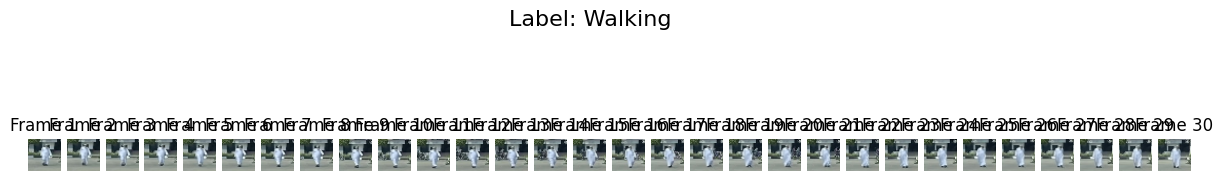

[INFO] Showing sequence 1 | Label: Walking


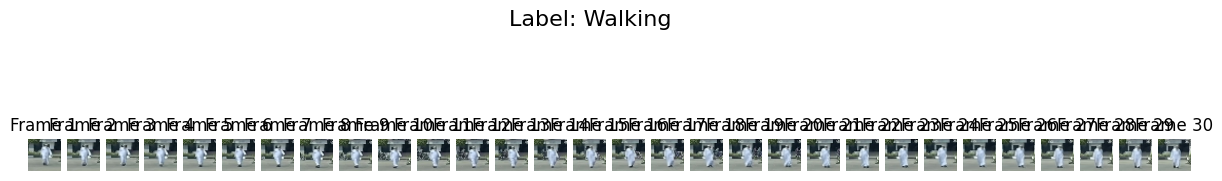

[INFO] Showing sequence 2 | Label: Walking


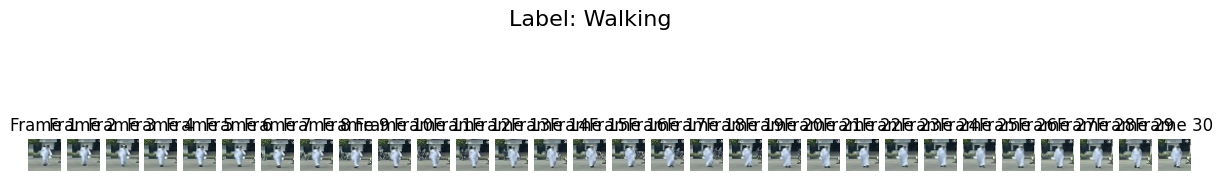

[INFO] Showing sequence 3 | Label: Walking


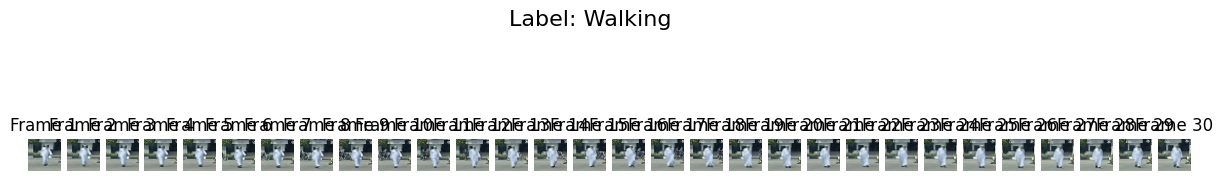

[INFO] Showing sequence 4 | Label: Walking


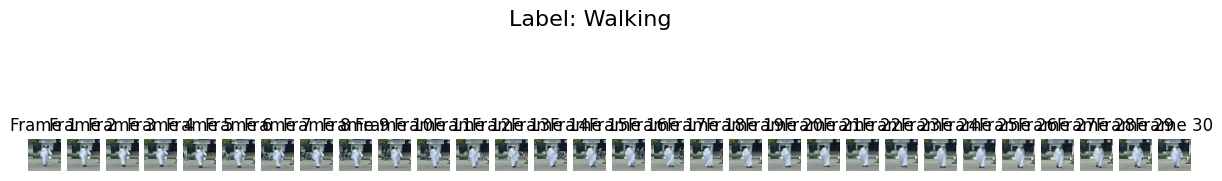

[INFO] Showing sequence 5 | Label: Walking


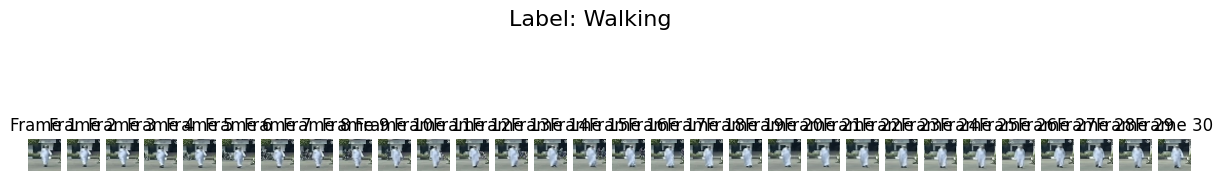

[INFO] Showing sequence 6 | Label: Walking


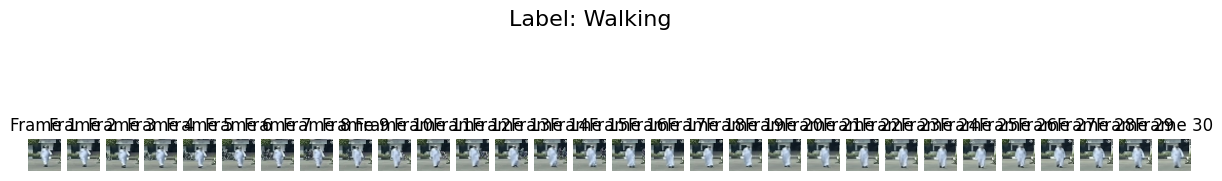

[INFO] Showing sequence 7 | Label: Walking


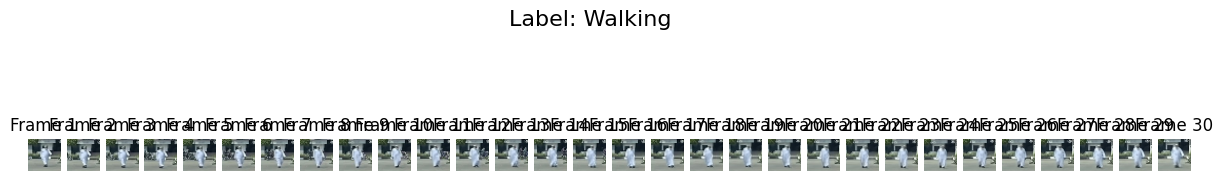

[INFO] Showing sequence 8 | Label: Walking


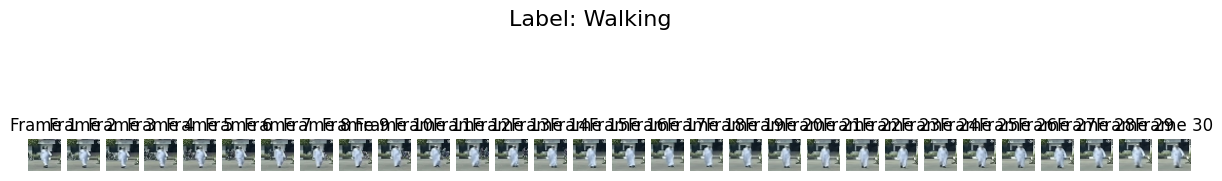

[INFO] Showing sequence 9 | Label: Walking


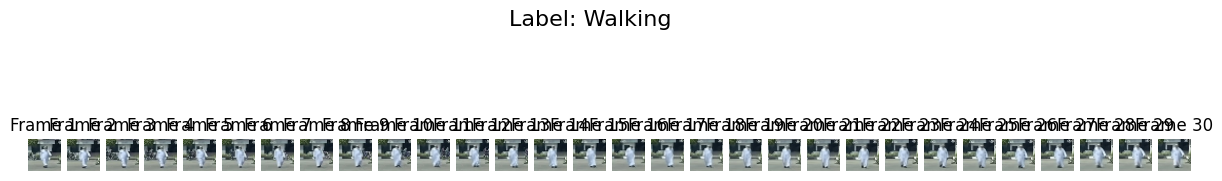

[INFO] Showing sequence 10 | Label: Walking


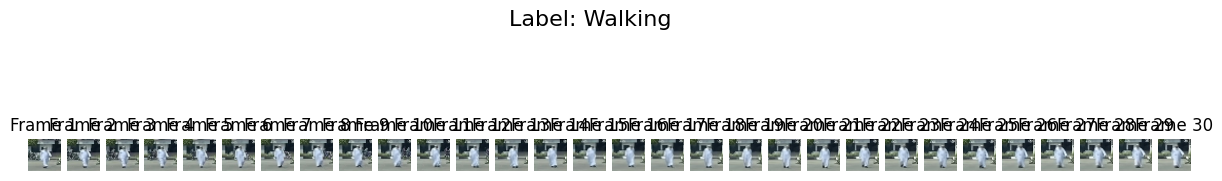

[INFO] Showing sequence 11 | Label: Walking


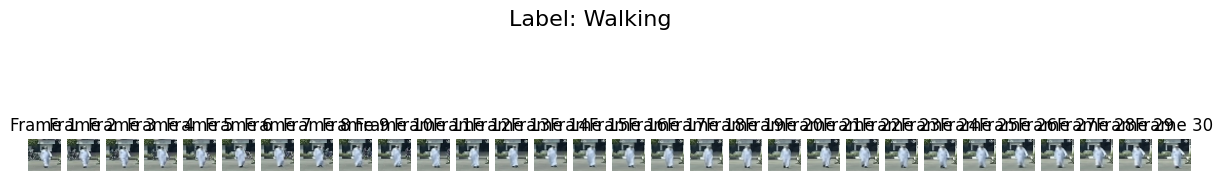

[INFO] Showing sequence 12 | Label: Walking


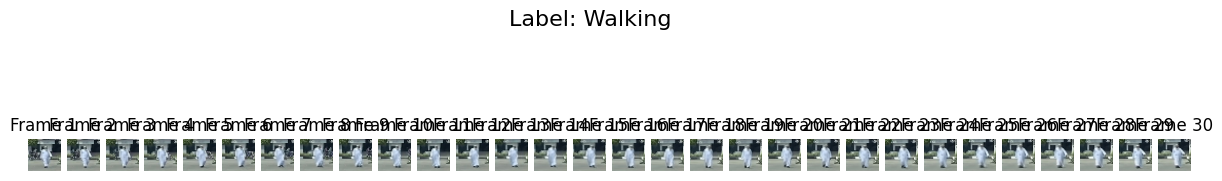

[INFO] Showing sequence 13 | Label: Walking


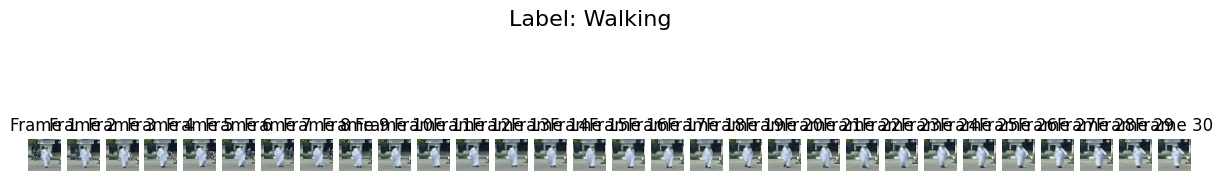

[INFO] Showing sequence 14 | Label: Walking


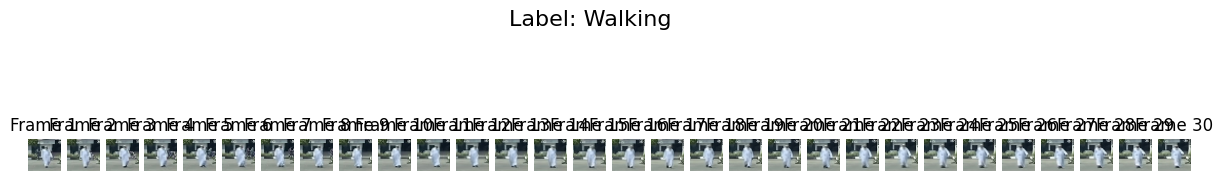

[INFO] Showing sequence 15 | Label: Walking


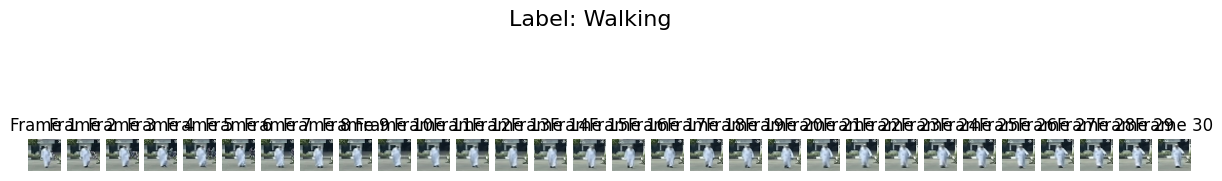

[INFO] Showing sequence 16 | Label: Walking


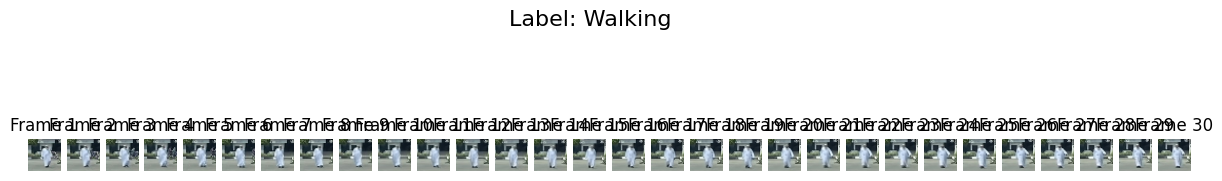

[INFO] Showing sequence 17 | Label: Walking


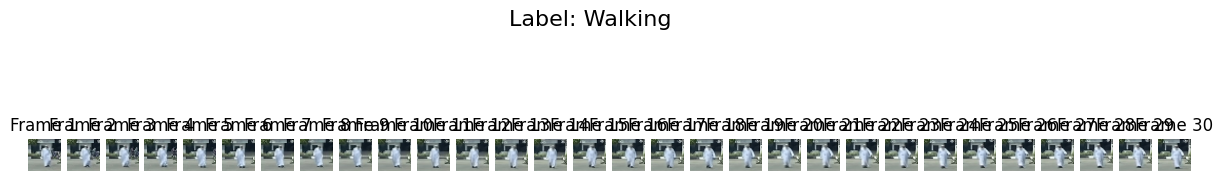

[INFO] Showing sequence 18 | Label: Walking


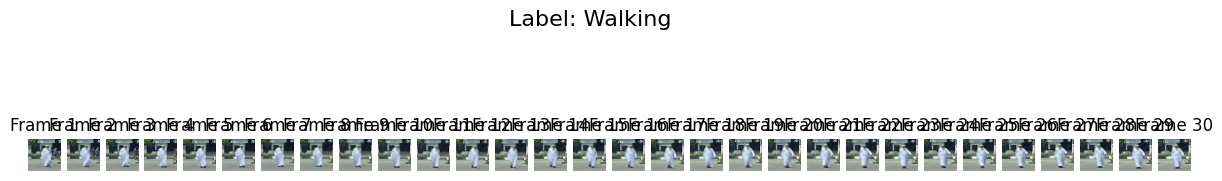

[INFO] Showing sequence 19 | Label: Walking


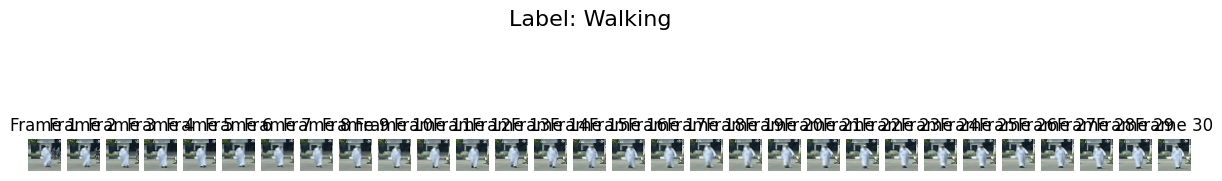

[INFO] Showing sequence 20 | Label: Walking


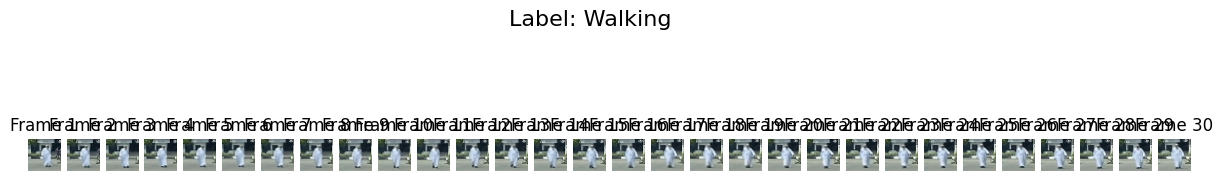

[INFO] Showing sequence 21 | Label: Walking


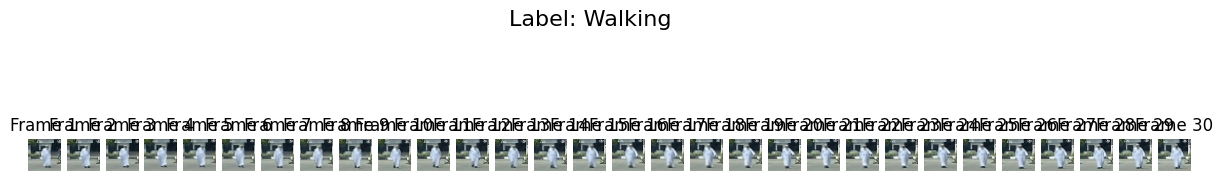

[INFO] Showing sequence 22 | Label: Walking


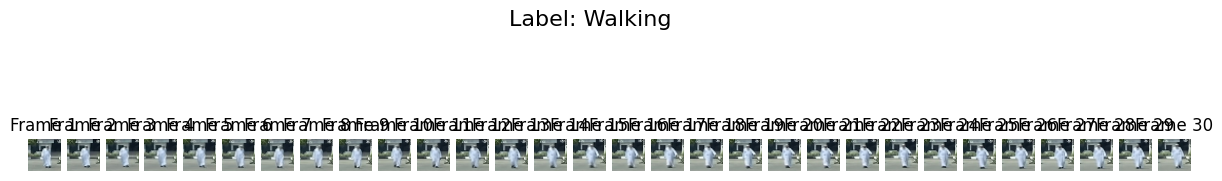

[INFO] Showing sequence 23 | Label: Walking


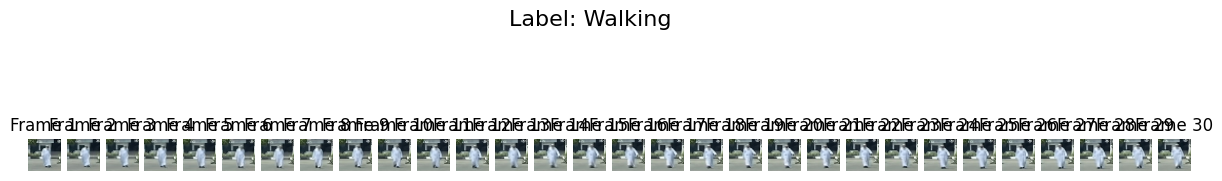

[INFO] Showing sequence 24 | Label: Walking


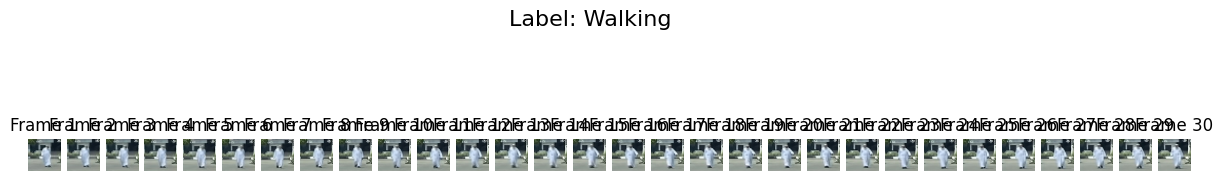

[INFO] Showing sequence 25 | Label: Walking


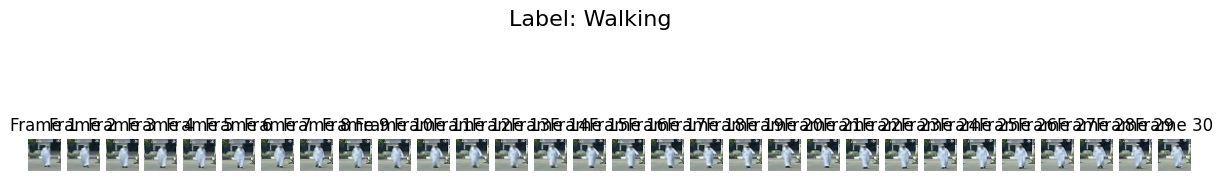

[INFO] Showing sequence 26 | Label: Walking


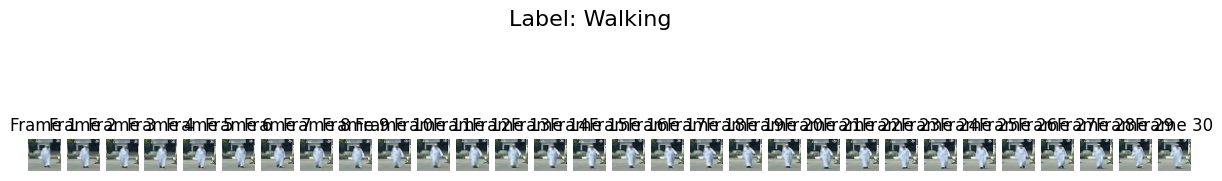

[INFO] Showing sequence 27 | Label: Walking


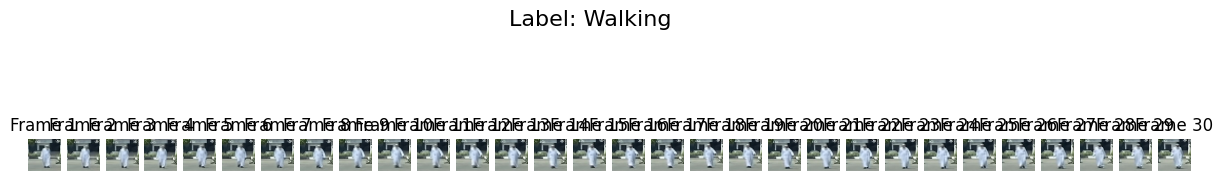

[INFO] Showing sequence 28 | Label: Walking


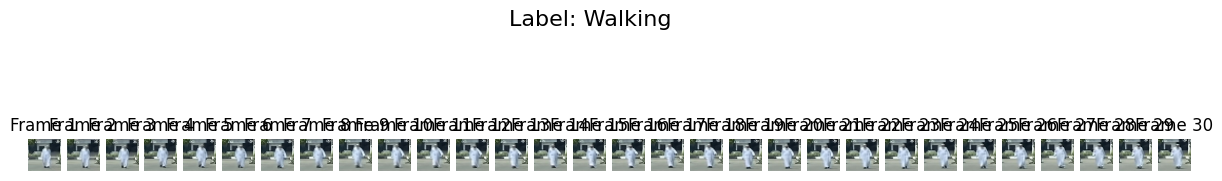

[INFO] Showing sequence 29 | Label: Walking


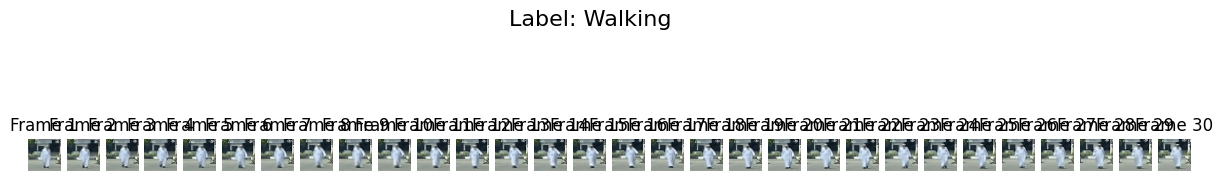

[INFO] Showing sequence 30 | Label: Walking


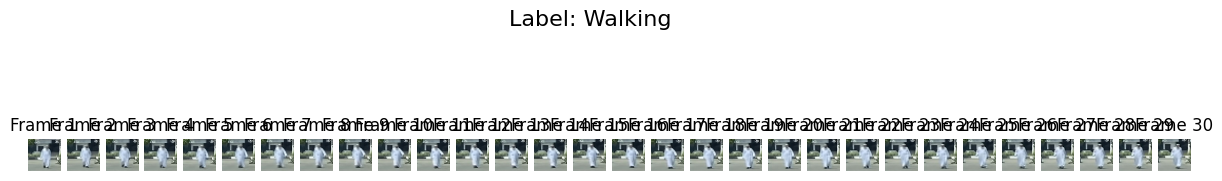

[INFO] Showing sequence 31 | Label: Walking


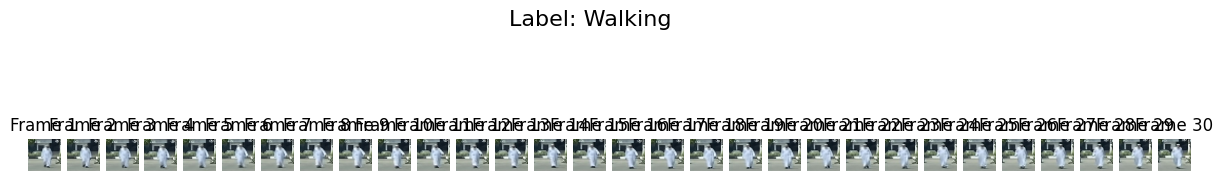

[INFO] Showing sequence 32 | Label: Walking


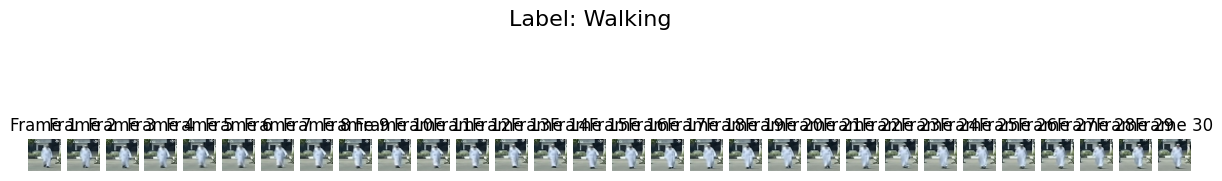

[INFO] Showing sequence 33 | Label: Walking


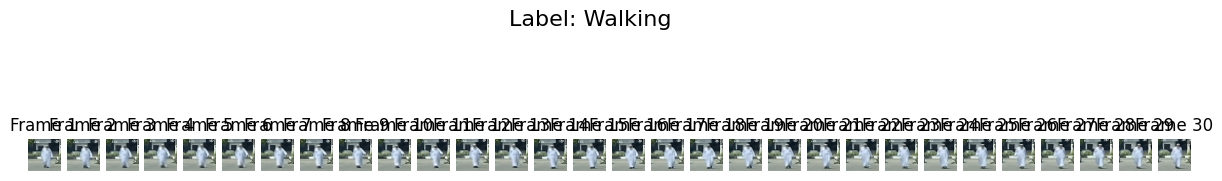

[INFO] Showing sequence 34 | Label: Walking


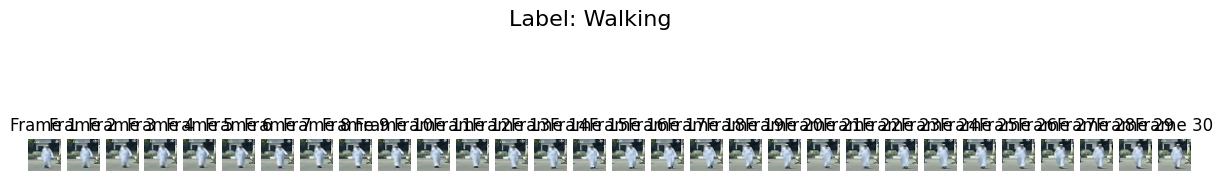

[INFO] Showing sequence 35 | Label: Walking


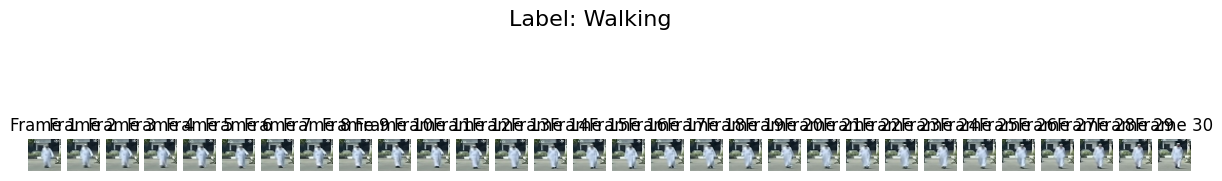

[INFO] Showing sequence 36 | Label: Walking


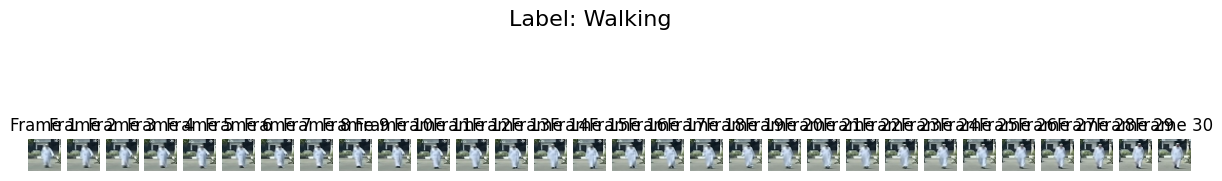

[INFO] Showing sequence 37 | Label: Walking


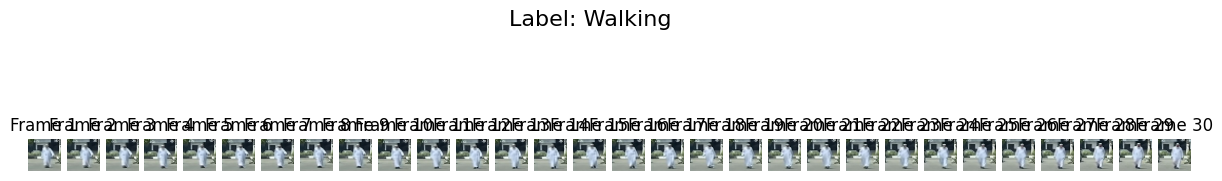

[INFO] Showing sequence 38 | Label: Walking


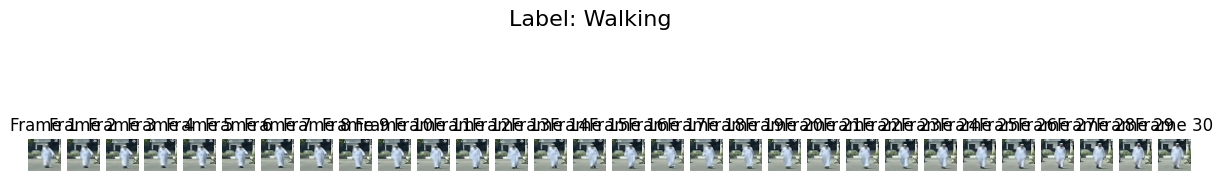

[INFO] Showing sequence 39 | Label: Walking


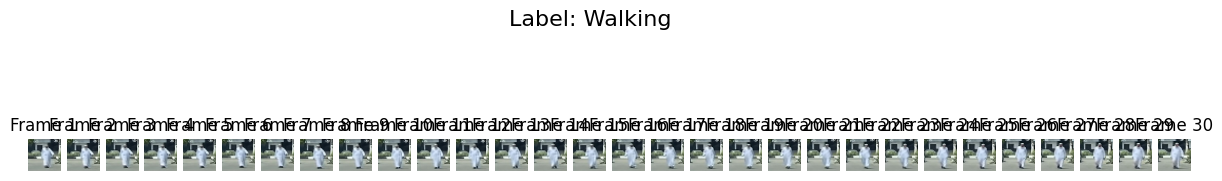

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved features and labels
# features = np.load("features.npy")
# labels = np.load("labels.npy")

# Reverse label map
LABELS_INV = {0: 'Walking', 1: 'Standing', 2: 'Crossing'}

# Visualize sequence using matplotlib
def visualize_sequence_matplotlib(sequence, label):
    plt.figure(figsize=(15, 3))
    for i, frame in enumerate(sequence):
        plt.subplot(1, len(sequence), i + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Frame {i+1}")
    plt.suptitle(f"Label: {LABELS_INV[label]}", fontsize=16)
    plt.show()

# Show the first 3 sequences
for i in range(40):
    print(f"[INFO] Showing sequence {i} | Label: {LABELS_INV[labels[i]]}")
    visualize_sequence_matplotlib(features[i], labels[i])


# Data Processing

In [4]:
import tensorflow as tf
import numpy as np

def augment_sequence(sequence):
    """
    Applies random augmentation to each frame in a sequence.
    Args:
        sequence: numpy array of shape (SEQUENCE_LENGTH, H, W, C)
    Returns:
        Augmented sequence (same shape)
    """
    augmented_frames = []

    for frame in sequence:
        frame = tf.convert_to_tensor(frame)

        # Apply augmentations
        frame = tf.image.random_flip_left_right(frame)
        frame = tf.image.random_brightness(frame, max_delta=0.2)
        frame = tf.image.random_contrast(frame, lower=0.8, upper=1.2)
        frame = tf.image.random_saturation(frame, lower=0.8, upper=1.2)

        augmented_frames.append(frame.numpy())

    return np.array(augmented_frames)


In [5]:
augmented_features = []
augmented_labels = []

for i in range(len(features)):
    original_seq = features[i]
    label = labels[i]

    # Add original
    augmented_features.append(original_seq)
    augmented_labels.append(label)

    # Add augmented
    new_seq = augment_sequence(original_seq)
    augmented_features.append(new_seq)
    augmented_labels.append(label)  # <-- This must be added too


In [6]:
augmented_features = np.array(augmented_features)
augmented_labels = np.array(augmented_labels)

In [7]:
print(f"[INFO] Original samples: {len(features)}, After Augmentation: {len(augmented_features)}")

[INFO] Original samples: 2406, After Augmentation: 4812


In [ ]:
# # # Define paths inside your Drive
# # features_path = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/augmented_features.npy"
# # labels_path = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/augmented_labels.npy"

# # Save them
# np.save(features_path, augmented_features)
# np.save(labels_path, augmented_labels)

# # print("[INFO] Augmented data saved to Google Drive.")

In [8]:
import numpy as np
import os

# Assume augmented_features and augmented_labels are numpy arrays
# Define paths to save them
features_path = 'saved_data/augmented_features.npy'
labels_path = 'saved_data/augmented_labels.npy'

# Make sure the directory exists
os.makedirs(os.path.dirname(features_path), exist_ok=True)

# Save them
np.save(features_path, augmented_features)
np.save(labels_path, augmented_labels)

print(f"Features saved to {features_path}")
print(f"Labels saved to {labels_path}")


Features saved to saved_data/augmented_features.npy
Labels saved to saved_data/augmented_labels.npy


In [ ]:
import numpy as np

# Define paths to load them
features_path = 'saved_data/augmented_features.npy'
labels_path = 'saved_data/augmented_labels.npy'

# Load the data
augmented_features = np.load(features_path)
augmented_labels = np.load(labels_path)

print("Features and labels loaded successfully.")
print(f"Features shape: {augmented_features.shape}")
print(f"Labels shape: {augmented_labels.shape}")


Features and labels loaded successfully.
Features shape: (6748, 10, 128, 128, 3)
Labels shape: (6748,)


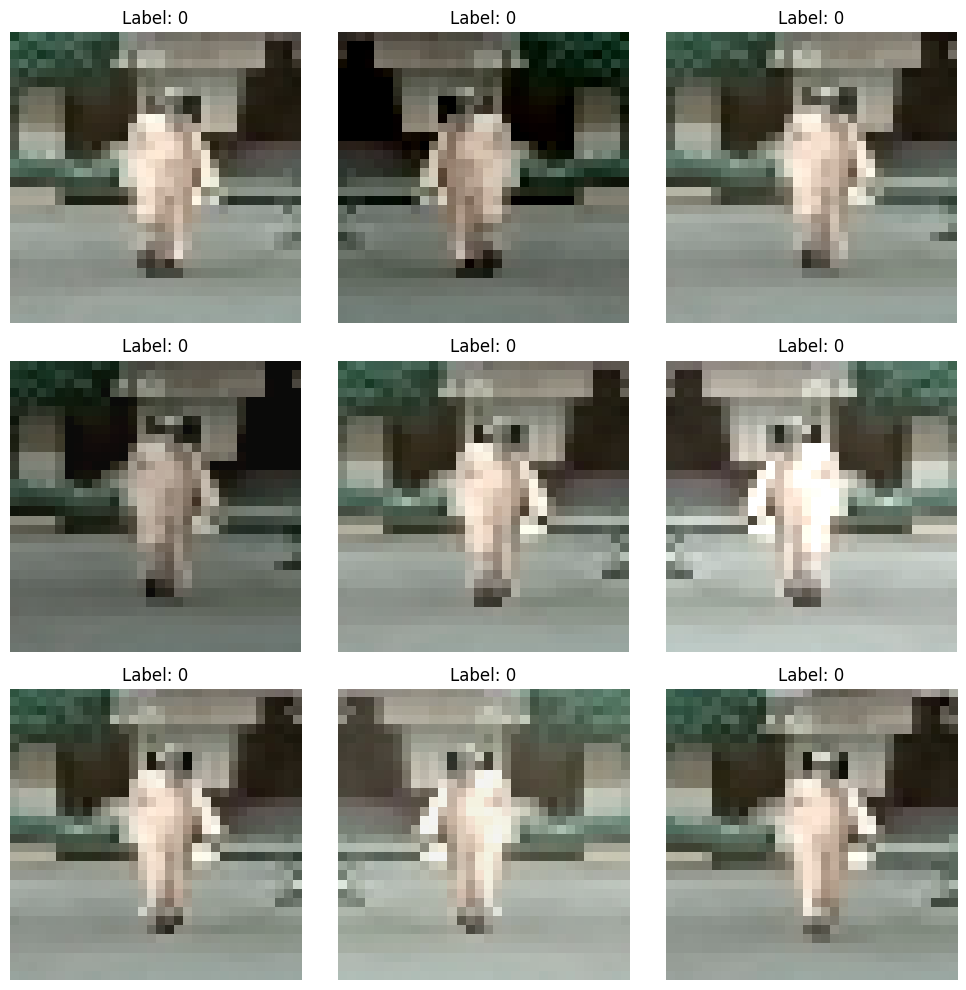

In [9]:
# Visualize the first frame from several sequences
num_samples_to_show = 9
plt.figure(figsize=(10, 10))

for i in range(num_samples_to_show):
    plt.subplot(3, 3, i + 1)

    first_frame = augmented_features[i][0]  # First frame of sequence i
    plt.imshow(first_frame.astype(np.uint8))  # Convert to uint8 if needed
    plt.title(f"Label: {augmented_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# First split: Train + Validation and Test
features_temp, features_test, labels_temp, labels_test = train_test_split(
    augmented_features, augmented_labels, test_size=0.2, random_state=42, stratify=augmented_labels
)

# Second split: Train and Validation (e.g., 20% of 80% = 16% of the original data for validation)
features_train, features_val, labels_train, labels_val = train_test_split(
    features_temp, labels_temp, test_size=0.2, random_state=42, stratify=labels_temp
)


In [ ]:
features_train.shape

(2159, 10, 128, 128, 3)

In [ ]:
labels_train.shape

(2159,)

In [17]:
np.save("saved_data/features_train.npy", features_train)
np.save("saved_data/features_val.npy", features_val)
np.save("saved_data/features_test.npy", features_test)

In [15]:
# labels_train = np.load("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/labels_train.npy")
# labels_val   = np.load("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/labels_val.npy")
# labels_test  = np.load("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/labels_test.npy")

In [16]:
features_train = features_train.astype(np.float32) / 255.0
features_val = features_val.astype(np.float32) / 255.0
features_test = features_test.astype(np.float32) / 255.0


In [18]:
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding (assuming 3 classes)
labels_train_one_hot = to_categorical(labels_train, num_classes=3)
labels_val_one_hot = to_categorical(labels_val, num_classes=3)
labels_test_one_hot = to_categorical(labels_test, num_classes=3)

In [19]:
# Save the one-hot encoded labels
np.save('saved_data/labels_train_one_hot.npy', labels_train_one_hot)
np.save('saved_data/labels_val_one_hot.npy', labels_val_one_hot)
np.save('saved_data/labels_test_one_hot.npy', labels_test_one_hot)

# Train  BI LRCN
TimeDistributed CNN + Bi-LSTM (i.e., an LRCN model with a bidirectional LSTM), which is a great choice for spatiotemporal data like video frames or sequential image data.



In [ ]:
# from tensorflow.keras.layers import LSTM, Bidirectional
# from tensorflow.keras.layers import Conv2D, TimeDistributed
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# # Constants
# SEQUENCE_LENGTH = 10  # or any desired sequence length
# IMAGE_HEIGHT = 128
# IMAGE_WIDTH = 128

# # Update to 3 output classes instead of
# CLASSES_LIST = {
#     0: 'walking',
#     1: 'standing',
#     2: 'crossing'
# }

# def create_LRCN_model():
#     '''
#     This function will construct the required LRCN model with Bi-LSTM.
#     Returns:
#         model: The constructed LRCN model.
#     '''

#     # We will use a Sequential model for model construction.
#     model = Sequential()

#     # Define the Model Architecture.
#     ########################################################################################################################

#     # TimeDistributed wrapper for 2D Convolution
#     model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same', activation='relu'),
#                               input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
#     model.add(TimeDistributed(MaxPooling2D((4, 4))))
#     model.add(TimeDistributed(Dropout(0.25)))

#     model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same', activation='relu')))
#     model.add(TimeDistributed(MaxPooling2D((4, 4))))
#     model.add(TimeDistributed(Dropout(0.25)))

#     model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
#     model.add(TimeDistributed(MaxPooling2D((2, 2))))
#     model.add(TimeDistributed(Dropout(0.25)))

#     model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
#     model.add(TimeDistributed(MaxPooling2D((2, 2))))

#     # Flatten the convolutional output
#     model.add(TimeDistributed(Flatten()))

#     # Use Bi-LSTM instead of LSTM
#     model.add(Bidirectional(LSTM(32)))  # Bidirectional LSTM for sequence learning

#     # Final output layer (softmax for classification with 3 output classes)
#     model.add(Dense(3, activation='softmax'))  # Updated to 3 output classes

#     ########################################################################################################################

#     # Display the models summary.
#     model.summary()

#     # Return the constructed LRCN model.
#     return model


In [20]:
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout
from tensorflow.keras.layers import Conv2D, TimeDistributed, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

# Constants
SEQUENCE_LENGTH = 30
IMAGE_HEIGHT = 32
IMAGE_WIDTH = 32

CLASSES_LIST = {
    0: 'walking',
    1: 'standing',
    2: 'crossing'
}

def create_LRCN_model():
    model = Sequential()

    # Convolutional layers (with TimeDistributed)
    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same', activation='relu'),
                              input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))  # smaller pooling
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    # Flatten
    model.add(TimeDistributed(Flatten()))

    # Bi-LSTM + Dropout
    model.add(Bidirectional(LSTM(32)))
    model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(3, activation='softmax'))

    model.summary()

    return model


In [37]:
# Construct the required LRCN model.
LRCN_model = create_LRCN_model() # Display the success message. print("Model Created Successfully!")

  super().__init__(**kwargs)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_10             │ (None, 30, 32, 32, 16) │           448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 30, 16, 16, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 30, 16, 16, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 30, 16, 16, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 30, 8, 8, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 30, 8, 8, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ (None, 30, 8, 8, 64)   │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_17             │ (None, 30, 4, 4, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_18             │ (None, 30, 4, 4, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_19             │ (None, 30, 1024)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │       270,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,371 (1.12 MB)

 Trainable params: 294,371 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

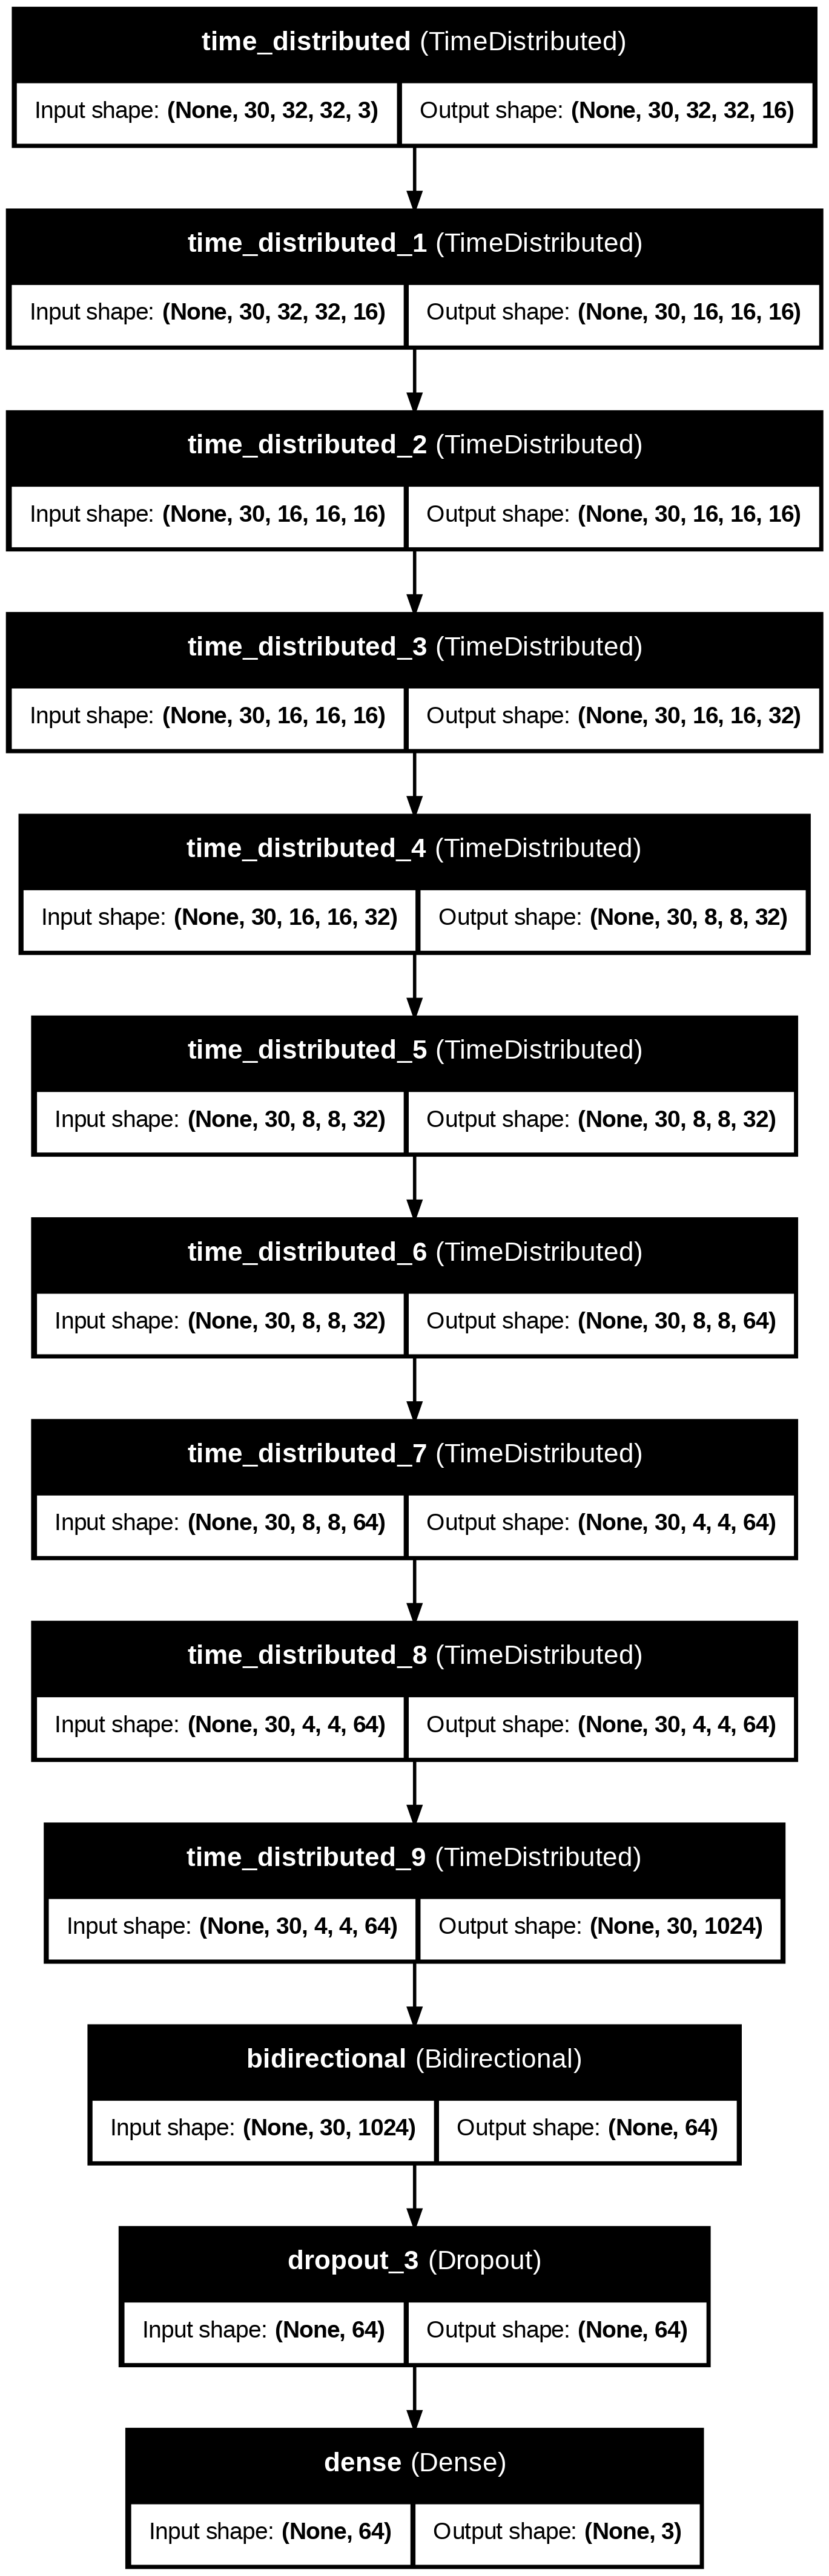

In [22]:
# Plot the structure of the contructed LRCN model.
plot_model(LRCN_model, to_file = 'LRCN_model_structure_plot.png', show_shapes = True, show_layer_names = True)

In [23]:
from tensorflow.keras.utils import to_categorical

# Define the class list based on the LABELS dict
classes_list = ['Walking', 'Standing', 'Crossing']  # Order must match LABELS dictionary



In [39]:
from tensorflow.keras.callbacks import EarlyStopping
from keras.optimizers import Adam

# Early stopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    restore_best_weights=True
)

# Compile model
LRCN_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# # Train the model using the explicit validation set
# LRCN_model_training_history = LRCN_model.fit(
#     x=features_train,
#     y=labels_train_one_hot,
#     epochs=10,
#     batch_size=32,
#     shuffle=True,
#     validation_data=(features_val, labels_val_one_hot),
#     callbacks=[early_stopping_callback],
#     verbose=1
# )


In [ ]:
import numpy as np
np.unique(labels, return_counts=True)


In [50]:
from sklearn.utils import class_weight
import numpy as np

# Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.2926112510495382), 1: np.float64(0.7107571560480148), 2: np.float64(1.2203725723345225)}


In [41]:
LRCN_model_training_history=LRCN_model.fit(
    x=features_train,
    y=labels_train_one_hot,
    epochs=20,
    batch_size=16,
    shuffle=True,
    validation_data=(features_val, labels_val_one_hot),
    callbacks=[early_stopping_callback],
    class_weight=class_weights,
    verbose=1
)


Epoch 1/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - accuracy: 0.3850 - loss: 1.0949 - val_accuracy: 0.5377 - val_loss: 1.0144
Epoch 2/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.5980 - loss: 0.9085 - val_accuracy: 0.5065 - val_loss: 1.0795
Epoch 3/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.6838 - loss: 0.7575 - val_accuracy: 0.6273 - val_loss: 0.8441
Epoch 4/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.7816 - loss: 0.5901 - val_accuracy: 0.6390 - val_loss: 0.8040
Epoch 5/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.8543 - loss: 0.4315 - val_accuracy: 0.7701 - val_loss: 0.6420
Epoch 6/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.8737 - loss: 0.3680 - val_accuracy: 0.8429 - val_loss: 0.5037
Epoch 7/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.9145 - loss: 0.2693 - val_accuracy: 0.7039 - val_loss: 0.6886
Epoch 8/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.8769 - loss: 0.3264 - 

In [ ]:
# import tensorflow as tf
# from tensorflow.keras import backend as K

# # Clear the current session to avoid the issue
# K.clear_session()

In [ ]:
# # Enable eager execution (for debugging purposes)
# tf.config.run_functions_eagerly(True)

In [42]:
# Now evaluate the model
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test_one_hot)

# Print evaluation results
print(f"Evaluation results: {model_evaluation_history}")


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9749 - loss: 0.1051
Evaluation results: [0.11984674632549286, 0.9698857665061951]


In [43]:
from sklearn.metrics import f1_score, accuracy_score

# Step 1: Get predictions
y_pred_probs = LRCN_model.predict(features_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 2: Convert one-hot true labels back to class indices
y_true = np.argmax(labels_test_one_hot, axis=1)

# Step 3: Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')  # or 'macro', 'micro' depending on preference

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step
Test Accuracy: 0.9699
Weighted F1 Score: 0.9702


In [51]:
# Get the loss and accuracy from model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Define the string date format.
# Get the current Date and Time in a DateTime Object.
# Convert the DateTime object to string according to the style mentioned in date_time_format string.
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models.
model_file_name = f'New LRCN_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.h5'

# Save the Model.
LRCN_model.save(model_file_name)

In [45]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
    '''
    This function will plot the metrics passed to it in a graph.
    Args:
        model_training_history: A history object containing a record of training and validation
                                loss values and metrics values at successive epochs
        metric_name_1:          The name of the first metric that needs to be plotted in the graph.
        metric_name_2:          The name of the second metric that needs to be plotted in the graph.
        plot_name:              The title of the graph.
    '''

    # Get metric values using metric names as identifiers.
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    # Construct a range object which will be used as x-axis (horizontal plane) of the graph.
    epochs = range(len(metric_value_1))

    # Plot the Graph.
    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)

    # Add title to the plot.
    plt.title(str(plot_name))

    # Add legend to the plot.
    plt.legend()

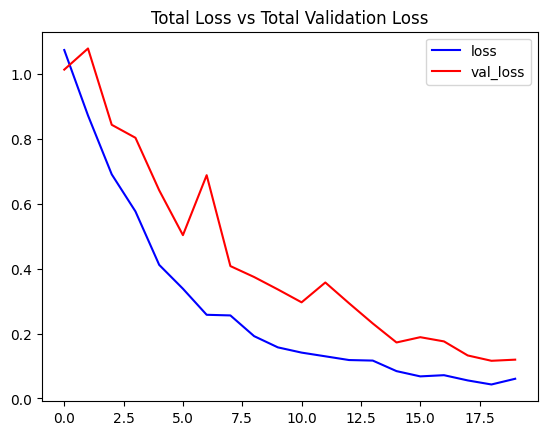

In [46]:
# Visualize the training and validation loss metrices.
plot_metric(LRCN_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

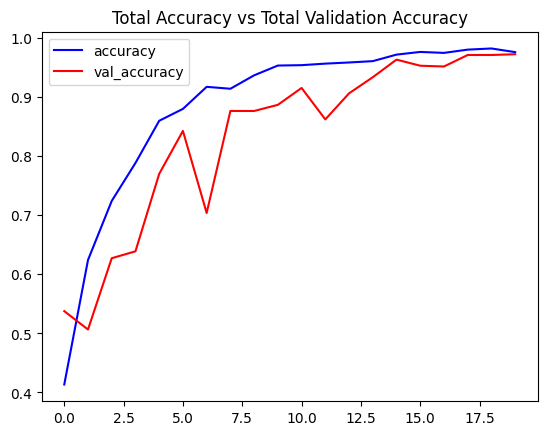

In [47]:
# Visualize the training and validation accuracy metrices.
plot_metric(LRCN_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

# Test the model

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predicted Labels Shape: (963,)
True Labels Shape: (963,)


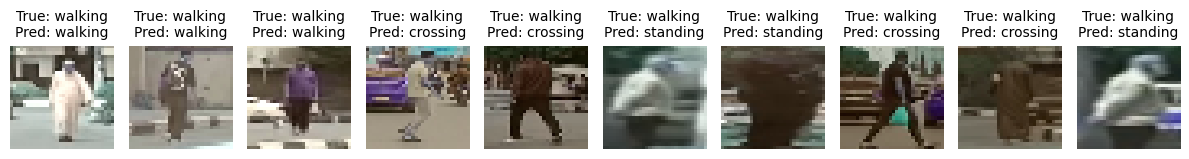

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Predict class probabilities for the test set
predictions = LRCN_model.predict(features_test)

# Convert probabilities to class indices
predicted_labels = np.argmax(predictions, axis=1)

# Print shapes for debugging
print("Predicted Labels Shape:", predicted_labels.shape)
print("True Labels Shape:", labels_test.shape)

# Visualize some test samples with their true and predicted labels
num_samples_to_show = 10 # Number of samples you want to visualize
plt.figure(figsize=(12, 8))

for i in range(num_samples_to_show):
    plt.subplot(1, num_samples_to_show, i + 1)

    # Get the image for the i-th sample
    image = features_test[i]  # Assuming features_test has shape (num_samples, SEQUENCE_LENGTH, H, W, C)

    # Rescale the image (if needed, based on how it's preprocessed)
    image = image[0]  # Get the first frame of the sequence (or adjust if necessary)

    # Plot image
    plt.imshow(image)

    # Get the true label
    true_label = np.argmax(labels_test[i])  # Assuming one-hot encoding

    # Get the predicted label
    predicted_label = predicted_labels[i]

    # Show true vs predicted labels on the plot
    plt.title(f'True: {CLASSES_LIST[true_label]}\nPred: {CLASSES_LIST[predicted_label]}', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [53]:
classes_list = {
    0: 'walking',
    1: 'standing',
    2: 'crossing'
}

In [54]:
%%capture
!pip install ultralytics==8.3.40

In [15]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Disables GPU

In [17]:
import cv2
import numpy as np
from collections import deque
from ultralytics import YOLO
from tensorflow.keras.models import load_model
import os

# Initialize variables
frames_pedestrians = []

# Paths
input_video_path = '/content/test.mov'
output_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/predicted_output.mp4'
yolo_path = "/content/yolo11s.pt"
lrcn_path = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/New LRCN_model___Date_Time_2025_05_01__09_32_37___Loss_0.11984674632549286___Accuracy_0.9698857665061951.h5"

# Parameters
SEQUENCE_LENGTH = 30
IMAGE_SIZE = 32
CLASSES_LIST = ["walking", "standing", "crossing"]
PREDICTION_COLORS = {
    "walking": (0, 255, 0),
    "standing": (0, 0, 255),
    "crossing": (0, 0, 128),
}

# Load models
print("[INFO] Loading models...")
yolo_model = YOLO(yolo_path)
LRCN_model = load_model(lrcn_path)

# Open input video
cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Prepare output video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Sequence buffer
sequence = deque(maxlen=SEQUENCE_LENGTH)
frame_count = 0
processed_frames = 0

# Function to normalize frames
def normalize_frame(frame):
    return frame / 255.0

print("[INFO] Processing video...")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("[INFO] End of video or failed to read frame.")
            break

        processed_frames += 1
        frame_count += 1

        # Normalize the entire frame before passing it to YOLO model
        frame_normalized = normalize_frame(frame)

        # Get detections from YOLO
        results = yolo_model(frame_normalized)[0]

        # Process only people (class_id == 0)
        for detection in results.boxes.data:
            x1, y1, x2, y2, conf, cls = detection.cpu().numpy()
            class_id = int(cls)

            if class_id == 0:  # Class ID 0 corresponds to "person" in YOLO
                x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

                cropped = frame[y1:y2, x1:x2]
                if cropped.size == 0:
                    continue

                # Resize and normalize cropped frame
                processed = cv2.resize(cropped, (IMAGE_SIZE, IMAGE_SIZE))
                processed = normalize_frame(processed)

                sequence.append(processed)

                if len(sequence) == SEQUENCE_LENGTH:
                    input_seq = np.array(sequence).reshape(1, SEQUENCE_LENGTH, IMAGE_SIZE, IMAGE_SIZE, 3)
                    prediction = LRCN_model.predict(input_seq, verbose=0)
                    predicted_class = np.argmax(prediction)
                    predicted_label = CLASSES_LIST[predicted_class]
                    color = PREDICTION_COLORS[predicted_label]

                    # Draw the bounding box and label on the frame
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, predicted_label, (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        out.write(frame)
        frames_pedestrians.append(frame)

        if frame_count % 5 == 0:
            print(f"[INFO] Processed {frame_count} frames...")

finally:
    cap.release()
    out.release()
    print(f"[DONE] Processed {processed_frames} frames out of {frame_count}.")
    print(f"[INFO] Prediction video saved to: {output_video_path}")


[INFO] Loading models...


[INFO] Processing video...

0: 320x640 (no detections), 18.0ms
Speed: 40.8ms preprocess, 18.0ms inference, 0.7ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 (no detections), 10.7ms
Speed: 8.4ms preprocess, 10.7ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 (no detections), 16.1ms
Speed: 11.4ms preprocess, 16.1ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 (no detections), 12.6ms
Speed: 9.2ms preprocess, 12.6ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 (no detections), 10.7ms
Speed: 7.4ms preprocess, 10.7ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)
[INFO] Processed 5 frames...

0: 320x640 (no detections), 10.7ms
Speed: 8.4ms preprocess, 10.7ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 (no detections), 15.4ms
Speed: 8.8ms preprocess, 15.4ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640

In [19]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
# import cv2
# import numpy as np
# from collections import deque
# from ultralytics import YOLO
# from tensorflow.keras.models import load_model
# import os

# # Initialize variables
# frames_pedestrians = []

# # Paths
# input_video_path = '/content/test.mov'
# output_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/predicted_output.mp4'
# yolo_path = "/content/yolo11s.pt"
# lrcn_path = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/New LRCN_model___Date_Time_2025_05_01__09_32_37___Loss_0.11984674632549286___Accuracy_0.9698857665061951.h5"

# # Parameters
# SEQUENCE_LENGTH = 30
# IMAGE_SIZE = 32
# CLASSES_LIST = ["walking", "standing", "crossing"]
# PREDICTION_COLORS = {
#     "walking": (0, 255, 0),
#     "standing": (0, 0, 255),
#     "crossing": (0, 0, 128),
# }

# # Load models
# print("[INFO] Loading models...")
# yolo_model = YOLO(yolo_path)
# LRCN_model = load_model(lrcn_path)

# # Open input video
# cap = cv2.VideoCapture(input_video_path)
# width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# fps = cap.get(cv2.CAP_PROP_FPS)

# # Prepare output video writer
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# # Sequence buffer
# sequence = deque(maxlen=SEQUENCE_LENGTH)
# frame_count = 0
# processed_frames = 0

# print("[INFO] Processing video...")

# try:
#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             print("[INFO] End of video or failed to read frame.")
#             break

#         processed_frames += 1
#         frame_count += 1

#         # Get detections from YOLO
#         results = yolo_model(frame)[0]

#         # Process only people (class_id == 0)
#         for detection in results.boxes.data:
#             x1, y1, x2, y2, conf, cls = detection.cpu().numpy()
#             class_id = int(cls)

#             if class_id == 0:  # Class ID 0 corresponds to "person" in YOLO
#                 x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

#                 cropped = frame[y1:y2, x1:x2]
#                 if cropped.size == 0:
#                     continue

#                 # Resize the cropped frame
#                 processed = cv2.resize(cropped, (IMAGE_SIZE, IMAGE_SIZE))

#                 sequence.append(processed)

#                 if len(sequence) == SEQUENCE_LENGTH:
#                     input_seq = np.array(sequence).reshape(1, SEQUENCE_LENGTH, IMAGE_SIZE, IMAGE_SIZE, 3)
#                     prediction = LRCN_model.predict(input_seq, verbose=0)
#                     predicted_class = np.argmax(prediction)
#                     predicted_label = CLASSES_LIST[predicted_class]
#                     color = PREDICTION_COLORS[predicted_label]

#                     # Draw the bounding box and label on the frame
#                     cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
#                     cv2.putText(frame, predicted_label, (x1, y1 - 10),
#                                 cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

#         out.write(frame)
#         frames_pedestrians.append(frame)

#         if frame_count % 5 == 0:
#             print(f"[INFO] Processed {frame_count} frames...")

# finally:
#     cap.release()
#     out.release()
#     print(f"[DONE] Processed {processed_frames} frames out of {frame_count}.")
#     print(f"[INFO] Prediction video saved to: {output_video_path}")


In [21]:
# from IPython.display import HTML, Video, Image, clear_output
# from matplotlib import animation, rc
# import numpy as np
# import matplotlib.pyplot as plt
# rc('animation', html='jshtml')

# # Define create_animation function
# def create_animation(ims):
#     fig = plt.figure(figsize=(10, 6))
#     im = plt.imshow(cv2.cvtColor(ims[0], cv2.COLOR_BGR2RGB))
#     plt.axis('off')
#     plt.close()

#     def animate_func(i):
#         im.set_array(cv2.cvtColor(ims[i], cv2.COLOR_BGR2RGB))
#         return [im]

#     return animation.FuncAnimation(fig, animate_func, frames=len(ims), interval=1000 // 3)

# # Call the create_animation function with processed_frames
# animation_obj = create_animation(np.array(frames_pedestrians))

# # Display the animation
# HTML(animation_obj.to_jshtml())

### Model conclusion

In [ ]:
import collections
print(collections.Counter(labels))  # where labels is your class ID list

In [ ]:
prediction = LRCN_model.predict(input_seq, verbose=0)
print("Raw prediction:", prediction)


In [ ]:
# Get the class with the highest probability
predicted_class = np.argmax(prediction)

# Mapping the predicted class to its corresponding label
predicted_label = CLASSES_LIST[predicted_class]

# Print the result
print(f"Predicted Class Index: {predicted_class}")
print(f"Predicted Label: {predicted_label}")
print(f"Prediction Probabilities: {prediction}")


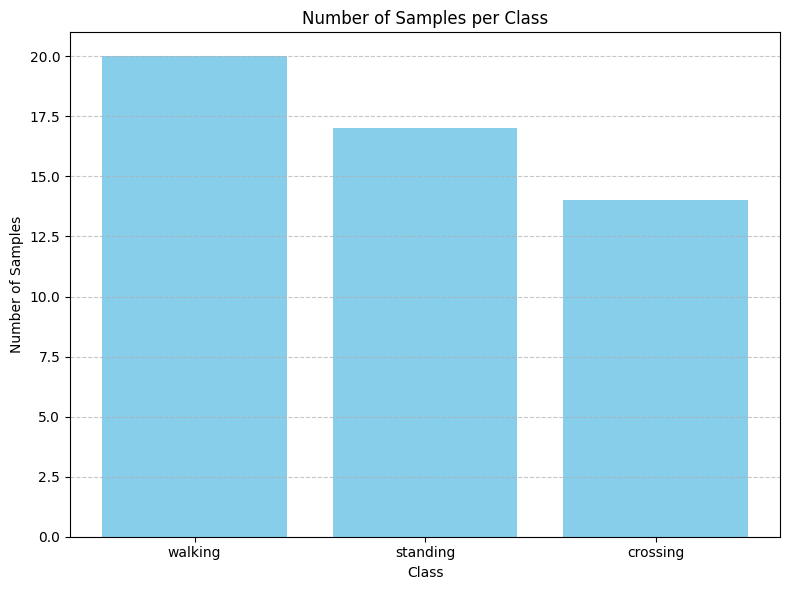

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Class label mapping
classes_list = {
    0: 'walking',
    1: 'standing',
    2: 'crossing'
}

# Simulate example label data (replace with actual labels)
labels_train = np.random.randint(0, 3, 51)

# Count occurrences of each class
unique, counts = np.unique(labels_train, return_counts=True)

# Map class indices to class names
class_names = [classes_list[i] for i in unique]

# Plot the results
plt.figure(figsize=(8, 6))
plt.bar(class_names, counts, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Number of Samples per Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
